# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Load Dataset

In [2]:
df = pd.read_csv('online_retail_II.csv')

# Data Cleaning & Preprocessing

In [3]:

df_clean = df.dropna(subset=['Customer ID']).query('Quantity > 0').copy()
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


# Scaling

In [4]:
rfm_log = np.log1p(rfm)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log)
X_scaled_df = pd.DataFrame(X_scaled, index=rfm.index, columns=rfm.columns)
X_scaled_df.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.856321,1.254938,3.170387
12347.0,-2.151924,0.800635,1.291999
12348.0,-0.079383,0.299705,0.557317
12349.0,-0.935429,0.074457,1.119681
12350.0,0.824152,-1.057568,-0.729063


# Hierarchical Clustering (Dendrogram Visual)

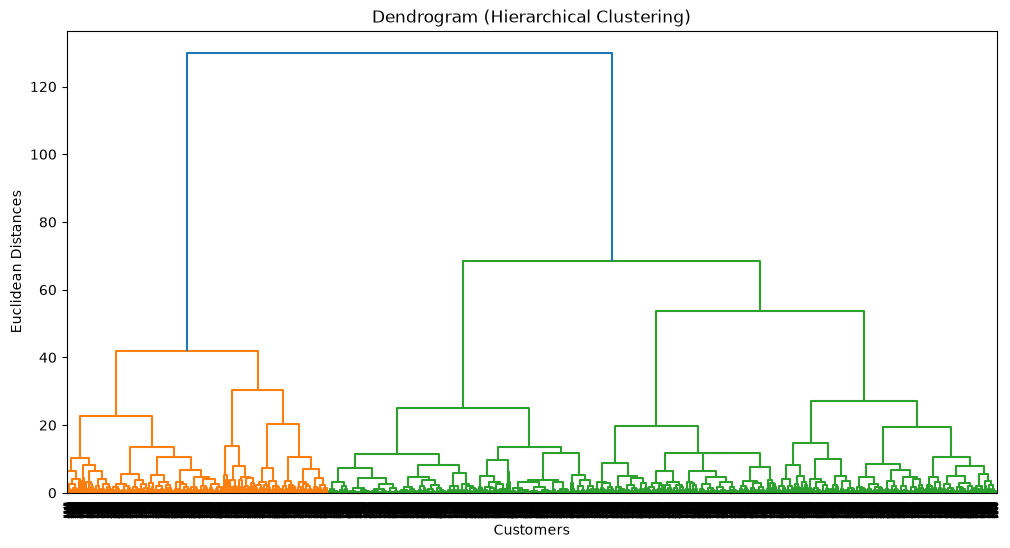

In [5]:
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()

# K-Means Clustering (Elbow Method)

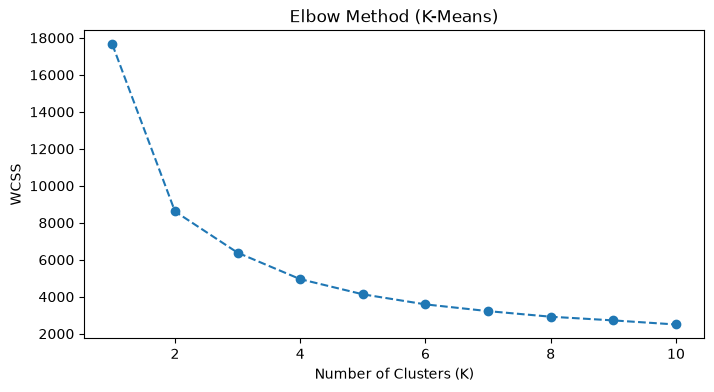

In [6]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method (K-Means)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

# Training The Models

In [7]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
hierarchical = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
y_hierarchical = hierarchical.fit_predict(X_scaled)
rfm['Cluster_KMeans'] = y_kmeans
rfm['Cluster_Hierarchical'] = y_hierarchical

# Model Evaluation

In [8]:
sil_kmeans = silhouette_score(X_scaled, y_kmeans)
sil_hierarchical = silhouette_score(X_scaled, y_hierarchical)
db_kmeans = davies_bouldin_score(X_scaled, y_kmeans)
db_hierarchical = davies_bouldin_score(X_scaled, y_hierarchical)
print(f"K-Means -> Silhouette Score: {sil_kmeans:.4f} | Davies-Bouldin Index: {db_kmeans:.4f}")
print(f"Hierarchical -> Silhouette Score: {sil_hierarchical:.4f} | Davies-Bouldin Index: {db_hierarchical:.4f}")

K-Means -> Silhouette Score: 0.3663 | Davies-Bouldin Index: 0.9355
Hierarchical -> Silhouette Score: 0.3314 | Davies-Bouldin Index: 0.9317


# Side-by-Side Visualization

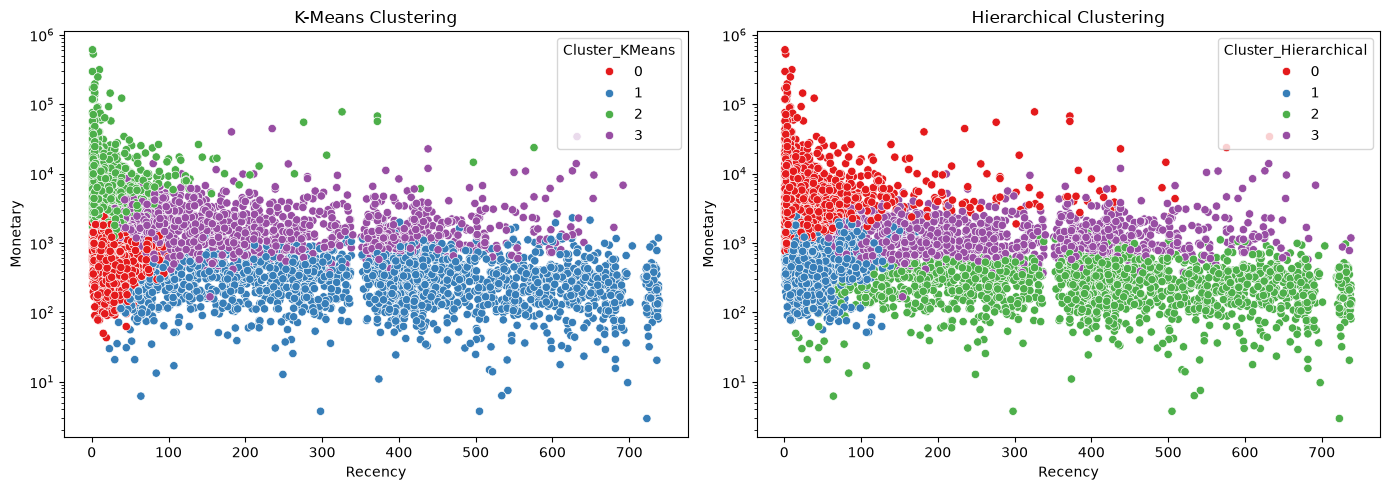

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster_KMeans', palette='Set1', ax=ax1)
ax1.set_yscale('log')
ax1.set_title('K-Means Clustering')
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster_Hierarchical', palette='Set1', ax=ax2)
ax2.set_yscale('log')
ax2.set_title('Hierarchical Clustering')
plt.tight_layout()
plt.show()